In [1]:
#########
# SCIKIT LAB
########
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("./AirQualityUCI.csv", sep=";", decimal=",")
# Чистка данных
df = df.dropna(how="all", axis=1).dropna(how="all", axis=0)
df.replace(-200, np.nan, inplace=True)
df = df.dropna()

In [2]:
## 1.
from sklearn.linear_model import LinearRegression

x_c6h6 = df[["C6H6(GT)"]]  # X
y_cogt = df["CO(GT)"]  # Y

x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(
    x_c6h6, y_cogt, test_size=0.2, random_state=42
)

linear_regression = LinearRegression()
linear_regression.fit(x_train_1, y_train_1)

cogt_pred = linear_regression.predict(x_test_1)

mse = mean_squared_error(y_test_1, cogt_pred)
r2 = r2_score(y_test_1, cogt_pred)

print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")



MSE: 0.1059
R2 Score: 0.9491


In [16]:
# 2
from sklearn.linear_model import LinearRegression

X = df[["C6H6(GT)", "T", "RH", "NO2(GT)"]]
Y = df["CO(GT)"]

X_Train, X_Test, Y_Train, Y_Test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)


linear_regression = LinearRegression()
linear_regression.fit(X_Train, Y_Train)
y_pred = linear_regression.predict(X_Test)

mse = mean_squared_error(Y_Test, y_pred)
r2 = r2_score(Y_Test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

MSE: 0.0757
R2 Score: 0.9636


In [7]:
# 3
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X = df[["C6H6(GT)", "T", "RH", "NO2(GT)"]]
Y = df["CO(GT)"]

X_Train, X_Test, Y_Train, Y_Test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()

X_Train = scaler.fit_transform(X_Train)
X_Test = scaler.transform(X_Test)

linear_regression = LinearRegression()
linear_regression.fit(X_Train, Y_Train)
y_pred = linear_regression.predict(X_Test)

mse = mean_squared_error(Y_Test, y_pred)
r2 = r2_score(Y_Test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

MSE: 0.0757
R2 Score: 0.9636


In [11]:
# 4

from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler

target = "CO(GT)"
features = df.select_dtypes(include=[np.number]).columns.drop(target)

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_cv = LassoCV(cv=5, random_state=42, n_alphas=100)
lasso_cv.fit(X_train_scaled, y_train)

y_pred = lasso_cv.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
non_zero_coeffs = np.sum(lasso_cv.coef_ != 0)

print(f"Оптимальное значение alpha: {lasso_cv.alpha_:.6f}")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Количество используемых признаков (не нулевых): {non_zero_coeffs} из {len(features)}")

# Посмотрим, какие признаки Lasso оставила, а какие обнулила
importance = pd.Series(lasso_cv.coef_, index=features)
print("\nВеса признаков:")
print(importance.sort_values(ascending=False))

Оптимальное значение alpha: 0.001360
MSE: 0.0590
R2 Score: 0.9717
Количество используемых признаков (не нулевых): 11 из 12

Веса признаков:
C6H6(GT)         0.781051
NOx(GT)          0.336413
PT08.S1(CO)      0.297929
NMHC(GT)         0.219626
NO2(GT)          0.123970
AH               0.061051
PT08.S3(NOx)     0.046357
PT08.S2(NMHC)   -0.000000
RH              -0.058016
PT08.S4(NO2)    -0.098180
T               -0.139209
PT08.S5(O3)     -0.167466
dtype: float64


/home/usercommon/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


In [14]:
# 5
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

alphas = np.logspace(-3, 3, 100)
target = "CO(GT)"
features = df.select_dtypes(include=[np.number]).columns.drop(target)

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_cv = RidgeCV(cv=5, alphas=alphas)
ridge_cv.fit(X_train_scaled, y_train)

y_pred = ridge_cv.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Оптимальное значение alpha: {ridge_cv.alpha_:.6f}")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Посмотрим, какие признаки Ridge оставила, а какие обнулила
importance = pd.Series(ridge_cv.coef_, index=features)
print("\nВеса признаков:")
print(importance.sort_values(ascending=False))

Оптимальное значение alpha: 0.200923
MSE: 0.0579
R2 Score: 0.9722

Веса признаков:
C6H6(GT)         1.052321
NOx(GT)          0.350119
PT08.S1(CO)      0.341548
NMHC(GT)         0.199286
NO2(GT)          0.142412
AH               0.124247
PT08.S3(NOx)    -0.022722
RH              -0.129395
T               -0.203836
PT08.S5(O3)     -0.206381
PT08.S4(NO2)    -0.209019
PT08.S2(NMHC)   -0.247198
dtype: float64


In [18]:
# 6
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

X = df[["C6H6(GT)", "T", "RH", "NO2(GT)"]]
Y = df["CO(GT)"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
cv_r2 = cross_val_score(model, X, Y, cv=kf, scoring='r2')
cv_mse = -cross_val_score(model, X, Y, cv=kf, scoring='neg_mean_squared_error')

print("=== Результаты кросс-валидации ===")
print(f"R2 по фолдам: {cv_r2}")
print(f"Средний R2: {cv_r2.mean():.4f}")
print(f"Стандартное отклонение R2: {cv_r2.std():.4f}")

print(f"\nMSE по фолдам: {cv_mse}")
print(f"Средний MSE: {cv_mse.mean():.4f}")


=== Результаты кросс-валидации ===
R2 по фолдам: [0.96361586 0.96121566 0.96786989 0.96120463 0.95280677]
Средний R2: 0.9613
Стандартное отклонение R2: 0.0049

MSE по фолдам: [0.07573892 0.06154285 0.07291453 0.08039318 0.08638935]
Средний MSE: 0.0754


In [20]:
# 7
target = "CO(GT)"
all_features = df.select_dtypes(include=[np.number]).columns.drop(target)
df_clean = df.dropna(subset=[target] + list(all_features))

X = df_clean[all_features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_cv = LassoCV(cv=10, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

y_pred = lasso_cv.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
best_alpha = lasso_cv.alpha_
non_zero_count = np.sum(lasso_cv.coef_ != 0)

print(f"Оптимальное значение alpha (лямбда): {best_alpha:.6f}")
print(f"Количество ненулевых коэффициентов: {non_zero_count} из {len(all_features)}")
print(f"MSE на тестовой выборке: {mse:.4f}")
print(f"R2: {r2:.4f}")

importance = pd.Series(lasso_cv.coef_, index=all_features)
print("\nКоэффициенты модели:")
print(importance.sort_values(ascending=False))

Оптимальное значение alpha (лямбда): 0.001360
Количество ненулевых коэффициентов: 11 из 12
MSE на тестовой выборке: 0.0590
R2: 0.9717

Коэффициенты модели:
C6H6(GT)         0.781051
NOx(GT)          0.336413
PT08.S1(CO)      0.297929
NMHC(GT)         0.219626
NO2(GT)          0.123970
AH               0.061051
PT08.S3(NOx)     0.046357
PT08.S2(NMHC)   -0.000000
RH              -0.058016
PT08.S4(NO2)    -0.098180
T               -0.139209
PT08.S5(O3)     -0.167466
dtype: float64


In [21]:
# 8
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 1. Подготовка (используем очищенный df_clean из прошлых шагов)
# Возьмем основные признаки для наглядности
features = ["C6H6(GT)", "T", "RH", "NO2(GT)"]
target = "CO(GT)"
df_poly = df.dropna(subset=features + [target])

X = df_poly[features]
y = df_poly[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- ШАГ А: Обычная линейная регрессия (для сравнения) ---
lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)
y_pred_simple = lr_simple.predict(X_test)

# --- ШАГ Б: Полиномиальная регрессия (степень 2) ---
# 1. Генерируем признаки: [x1, x2] -> [1, x1, x2, x1^2, x1*x2, x2^2]
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 2. Обучаем ту же линейную регрессию, но на "раздутых" данных
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

# 3. Сравнение метрик
metrics = {
    "Simple Linear": {
        "MSE": mean_squared_error(y_test, y_pred_simple),
        "R2": r2_score(y_test, y_pred_simple)
    },
    "Polynomial (deg 2)": {
        "MSE": mean_squared_error(y_test, y_pred_poly),
        "R2": r2_score(y_test, y_pred_poly)
    }
}

print(pd.DataFrame(metrics).T)

                         MSE        R2
Simple Linear       0.075739  0.963616
Polynomial (deg 2)  0.058229  0.972027


,Модель,MSE,R2 Score
3,Ridge (L2) - Все признаки,0.0579,0.9722
4,Полиномиальная (deg 2),0.0582,0.9720
2,Lasso (L1) - Все признаки,0.0590,0.9717
1,Множественная (4 признака),0.0757,0.9636
0,Парная регрессия (C6H6),0.1059,0.9491


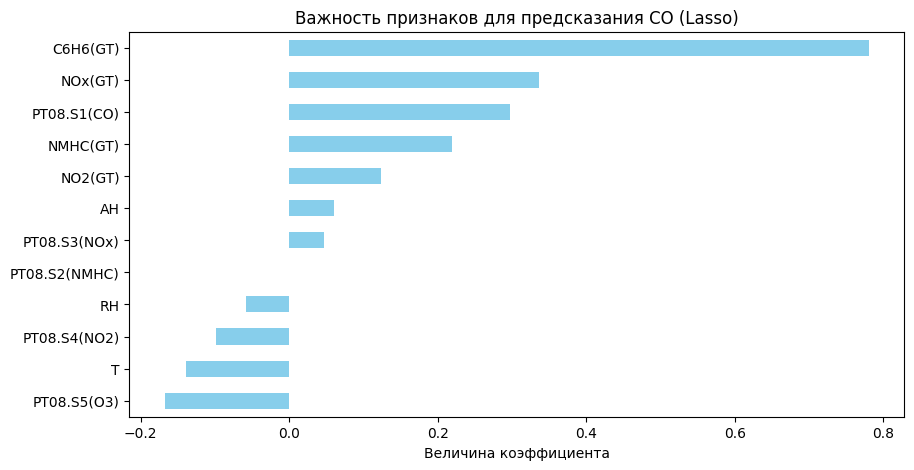

In [22]:
#9
final_metrics = {
    "Модель": [
        "Парная регрессия (C6H6)", 
        "Множественная (4 признака)", 
        "Lasso (L1) - Все признаки", 
        "Ridge (L2) - Все признаки", 
        "Полиномиальная (deg 2)"
    ],
    "MSE": [0.1059, 0.0757, 0.0590, 0.0579, 0.0582],
    "R2 Score": [0.9491, 0.9636, 0.9717, 0.9722, 0.9720]
}

comparison_df = pd.DataFrame(final_metrics)
display(comparison_df.sort_values(by="R2 Score", ascending=False))

# Визуализация важности признаков (возьмем веса из Lasso, т.к. они самые наглядные)
plt.figure(figsize=(10, 5))
importance.sort_values().plot(kind='barh', color='skyblue')
plt.title("Важность признаков для предсказания CO (Lasso)")
plt.xlabel("Величина коэффициента")
plt.show()